## Singular Value Decomposition
Any matrix $\bf A$ can be decomposed into model and data eigenvectors,
weighted by singular values:

$${\bf A} = \sum_i \sigma_i {\bf u}_i\cdot {\bf v}_i^T = {\bf U}{\bf \Sigma}{\bf V}^T$$

with the eigenvalues in $\Sigma=\text{diag}(\sigma_i)$, a set of orthogonal data eigenvectors ${\bf U}$ with ${\bf U}^{-1}={\bf U}^T$, and model eigenvectors ${\bf V}$ with ${\bf V}^{-1}={\bf V}^T$.


The eigenvectors associated with zero singular values ($\sigma_i=0$) span the null spaces of data and model. The number of (ordered descently) non-zero eigenvalues $p$ defines the rank of the matrix which can be abbreviated by

$${\bf A} = \sum_{i=1}^{p} \sigma_i {\bf u}\cdot {\bf v}^T = {\bf U}_p{\bf \Sigma}_p{\bf V}_p^T$$

where ${\bf B}_p$ holds the first $p$ columns of the matrix $\bf B$.

A matrix can be approximated by choosing the rank by hand.

The forward problem 
$${\bf G}{\bf m}={\bf d}$$
can be written in terms of SVD

$${\bf U}_p{\bf \Sigma}_p{\bf V}_p^T {\bf m}={\bf d}$$

can be rearranged by using ${\bf U}_p^T{\bf U}_p={\bf I}$ to

$${\bf \Sigma}_p{\bf V}_p^T {\bf m}={\bf U}^T_p{\bf d}$$

$${\bf V}_p^T {\bf m}={\bf \Sigma}^{-1}_p{\bf U}^T_p{\bf d}$$

$${\bf m}={\bf V}_p {\bf \Sigma}^{-1}_p{\bf U}^T_p{\bf d}$$


The generalized inverse ${\bf V}_p {\bf \Sigma}^{-1}_p{\bf U}^T_p$ is called the pseudo-inverse and equals 
$$({\bf G}^T{\bf G})^{-1}{\bf G}^T$$
i.e., the least-squares inverse for overdetermined problems.

By further truncating the number of nonzero singular values one can obtain a regularized solution for ill-posed (badly conditioned under-determined or mixed-determined) problems.

### Image compression by truncated SVD

We use the Images toolbox to load a greyscale image. `Pkg.add("Images")` might be necessary.

In [1]:
# using Pkg
# Pkg.add("Images")

In [2]:
using Images
img = load("rose8bit.png");

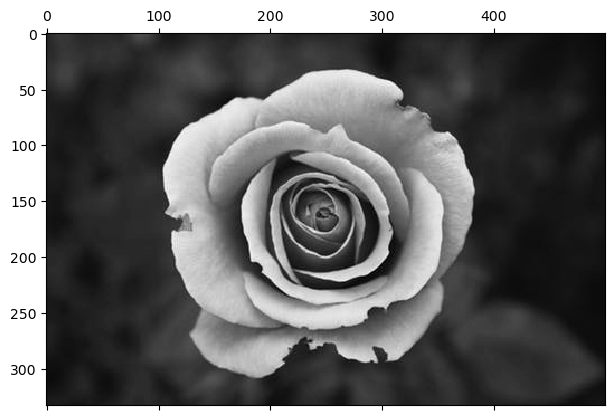

In [3]:
using PyPlot
grey = channelview(img)[1, :, :]
matshow(grey)
set_cmap("gray")

In [4]:
# Compute the SVD
using LinearAlgebra
s = svd(grey);

In [5]:
rank(grey)

333

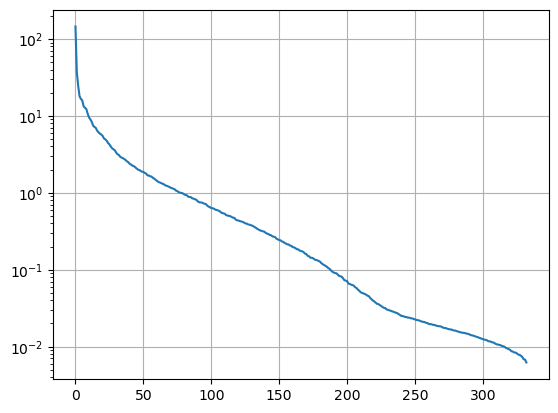

In [6]:
f = figure()
semilogy(s.S)
grid()

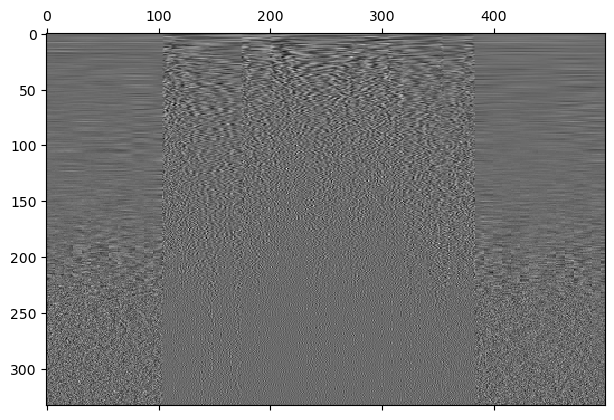

PyObject <matplotlib.image.AxesImage object at 0x00000131ABA26550>

In [7]:
matshow(s.Vt)

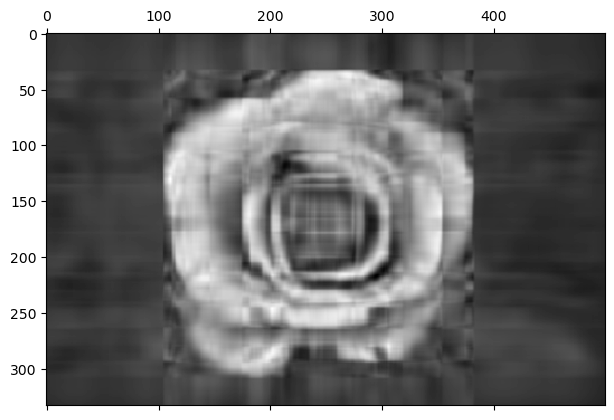

PyObject <matplotlib.image.AxesImage object at 0x000001319B1FC8D0>

In [8]:
p = 10
Ap = s.U[:, 1:p] * diagm(s.S[1:p]) * s.Vt[1:p, :]
matshow(Ap)

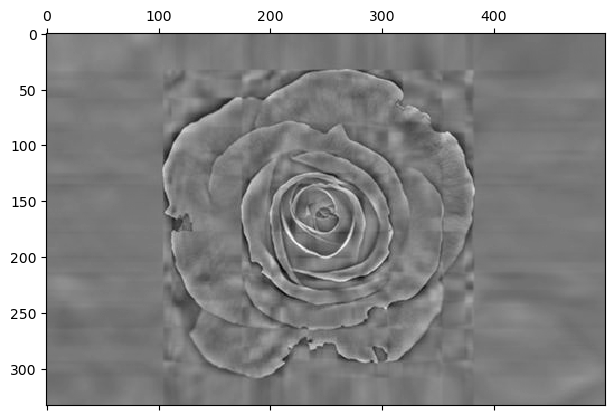

PyObject <matplotlib.image.AxesImage object at 0x00000131ABB73850>

In [9]:
matshow(grey-Ap)

WebIO._IJuliaInit()

167

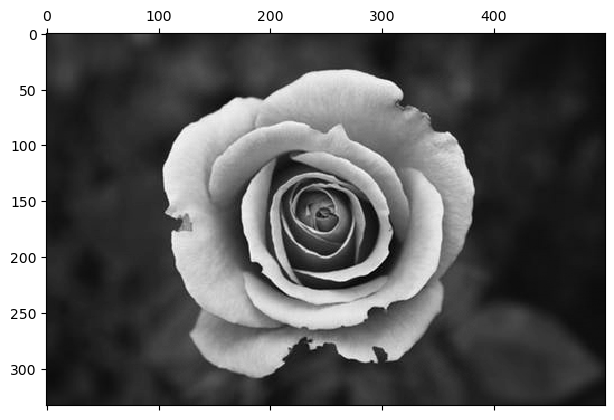

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["p"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 333, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable(167), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "C:\\Users\\Thomas Guenther\\.julia\\packages\\Knockout\\HReiN\\src\\..\\assets\\knockout.js"), Asset("js", "knockout_punches", "C:\\Users\\Thomas Guenther\\.julia\\packages\\Knockout\\HReiN\\src\\..\\assets\\knockout_punches.js"), Asset("js", nothing, "C:\\Users\\Thomas Guenther\\.julia\\packages\\InteractBase\\LJXv3\\src\\..\\assets\\all.js"), Asset("css", nothing, "C:\\Users\\Thomas Guenther\\.julia\\packages\\InteractBase\\LJXv3\\src\\..\\assets\\style.css"), Asset("css", nothing, "C:\\Users\\Thomas Guenther\\.julia\\packages\\Interact\\PENUy\\src\\..\\assets\\bulma_confined.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition{ReentrantLock}(Base.IntrusiveLinkedList{Task}(Task (runnable, started) @0x0000013197da22f0, Task (runnable, started) @0x0000013197da22f0), ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 0, 141733920768)))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"1\",\"2\",\"3\",\"4\",\"5\"

In [10]:
using Interact  # interactive plots
f=figure();
@manipulate for p = 1:length(s.S); withfig(f) do
        print(p)
        Ap = s.U[:, 1:p] * diagm(s.S[1:p]) * s.Vt[1:p, :]
        matshow(Ap);
    end
end

### Resolution in terms of SVD
The model resolution
$$ {\bf G}^\dagger {\bf G} = {\bf V}_p {\bf \Sigma}^{-1}_p{\bf U}^T_p {\bf U}_p{\bf \Sigma}_p{\bf V}_p^T = {\bf V}_p {\bf V}_p^T $$
depends only on the model eigenvectors!

And the data resolution
$$ {\bf G} {\bf G}^\dagger = {\bf U}_p{\bf \Sigma}_p{\bf V}_p^T {\bf V}_p {\bf \Sigma}^{-1}_p{\bf U}^T_p = {\bf U}_p {\bf U}_p^T $$
depends only on the data eigenvectors!

Let us look at the eigenvectors of the overdetermined matrix problem.

In [11]:
G = [1 -1;2 -1;1 1];
d = [-1; 0; 2.5];
s = svd(G)

SVD{Float64, Float64, Matrix{Float64}, Vector{Float64}}
U factor:
3×2 Matrix{Float64}:
 -0.507093   0.316228
 -0.845154  -7.62083e-17
 -0.169031  -0.948683
singular values:
2-element Vector{Float64}:
 2.6457513110645907
 1.414213562373095
Vt factor:
2×2 Matrix{Float64}:
 -0.894427   0.447214
 -0.447214  -0.894427

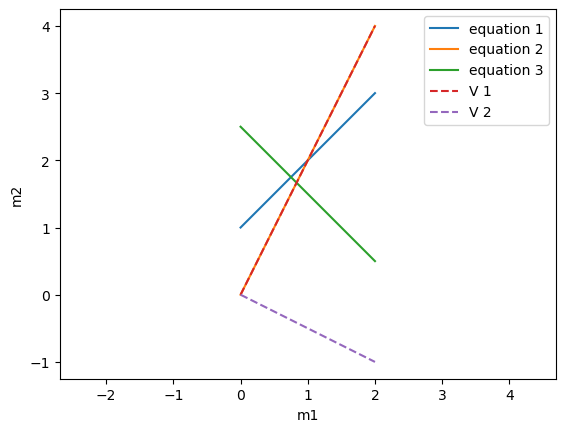

(-0.1, 2.1, -1.2500000000000004, 4.25)

In [12]:
xx = [0; 2]
f=figure()
for i in 1:3
    yy = (d[i] .- G[i, 1] * xx) ./ G[i,2]
    plot(xx, yy, label="equation $i") 
end
xlabel("m1")
ylabel("m2");
for i in 1:2
    yy = (+ s.V[i, 1] * xx) ./ s.V[i,2]
    plot(xx, yy, "--", label="V $i") 
end
legend()
axis("equal")

### Eigenvectors of the regression problem

2-element Vector{Float64}:
 10.913048571640049
  2.5407421894055084

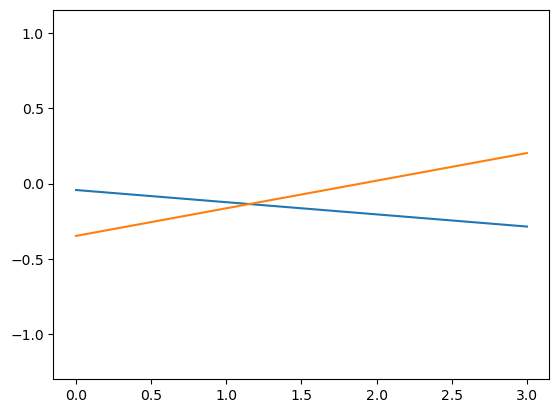

(-0.15000000000000002, 3.15, -0.37563114475083725, 0.23066762480711733)

In [13]:
x = 0:0.1:3.0
G = ones(length(x), 2)
G[:, 1] = x[:]  # column vector
s = svd(G)
display(s.S)
plot(x, s.U[:, 1])
plot(x, s.U[:, 2])
axis("equal")

In [14]:
A = [1 1 0 0;1 1.1 0 0;0 0 1 0.5;0 0 0.5 1]
s = svd(A)
print(round.(s.S, digits=2))

[2.05, 1.5, 0.5, 0.05]

In [15]:
AI = pinv(A, rtol=0.1)
m = [10;11;12;13]
d = A*m
print(round.(d, digits=2))

[21.0, 22.1, 18.5, 19.0]

In [16]:
error = 0.2
for i in 1:5
    dnoise = d + randn(4) * error
    mest = AI * dnoise
    print(round.(mest, digits=2))
    print("\n")
end


[10.1, 10.62, 12.21, 12.93]
[10.23, 10.75, 12.35, 12.84]
[10.21, 10.73, 12.51, 12.61]
[10.31, 10.84, 11.95, 12.9]
[10.25, 10.78, 11.97, 12.98]
